In [10]:
from trading.model_tools import ta_transform
import trading.model_tools as mt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### metrics

def r2_between(x: pd.Series, y: pd.Series) -> float:
    return x.corr(y) ** 2

def shannon_entropy(series: pd.Series, bins: int = 50) -> float:
    values = series.dropna().to_numpy()
    counts, _ = np.histogram(values, bins=bins)
    probs = counts[counts > 0] / counts.sum()
    return -np.sum(probs * np.log2(probs))

### transforms

def difference_transform(x: pd.Series, y: pd.Series) -> np.ndarray:
    return x.sub(y).to_numpy()

def acceleration_transform(x: pd.Series) -> np.ndarray:
    return x.diff(1).to_numpy()

def log_transform(x: pd.Series) -> np.ndarray:
    return np.log(x.to_numpy())

transforms = [difference_transform, acceleration_transform, log_transform]

###

data = mt.fetch_data(
    symbols=["SOL-USDT", "BTC-USDT"],
    days=730,
    interval="1h",
    age_days=0,
    data_source="binance",
    cache_expiry_hours=-1,
    verbose=True,
)

X = ta_transform(data, add_ticker="BTC-USDT")

FETCHING DATASET(S) SOL-USDT, BTC-USDT; 730d of 1h

USING CACHE C:\Users\fluidize\AppData\Roaming\market_data\SOL-USDT_BTC-USDT_730_1h_0_binance.csv (3.04 MB 17534 
bars)

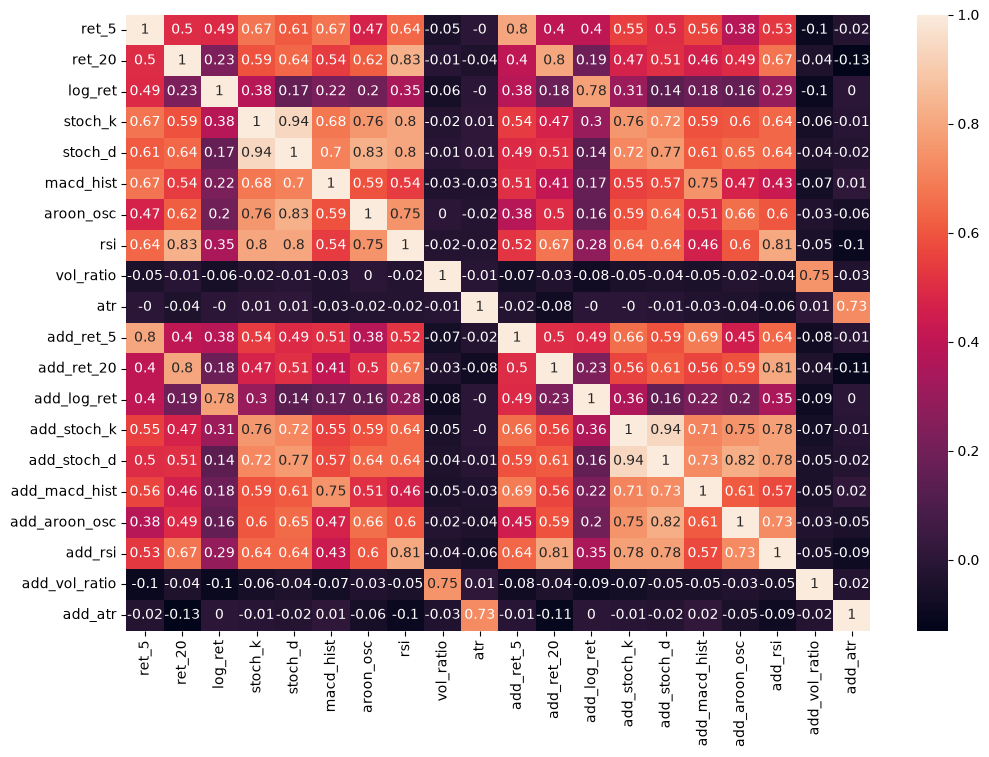

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(np.round(X.corr(), 2), annot=True)
plt.show()

C:\Users\fluidize\AppData\Local\Temp\ipykernel_34464\3762380748.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x.to_numpy())


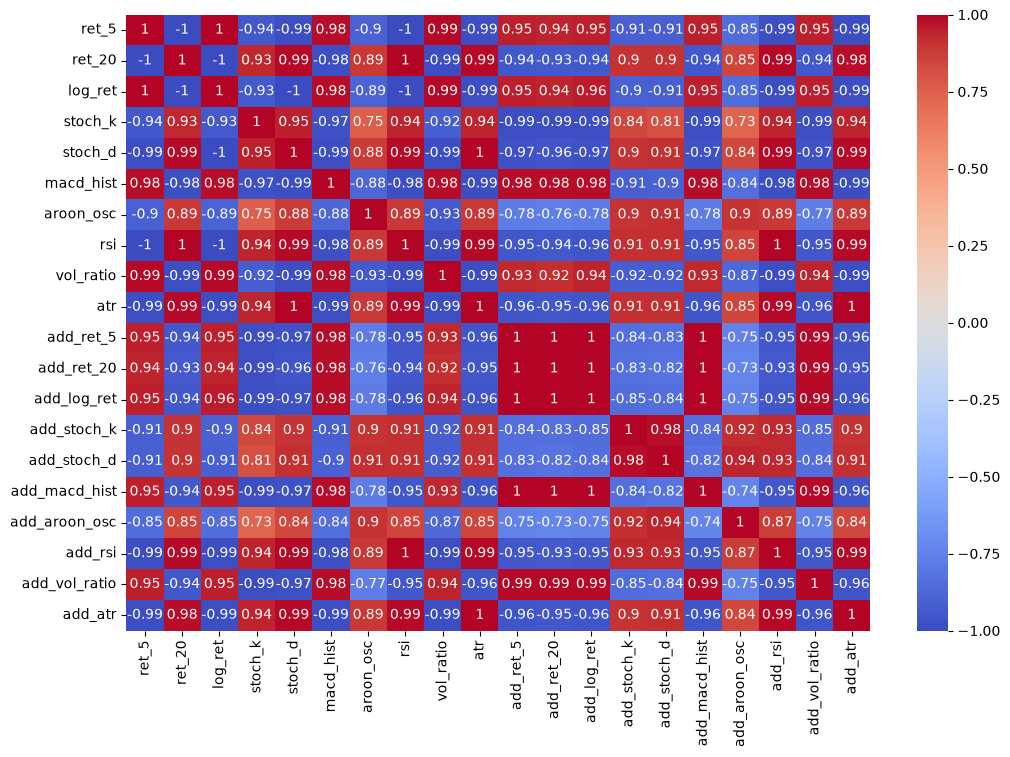

In [12]:

columns = X.columns

for col in columns:
    max_entropy = 0
    max_entropy_series = None
    for transform in transforms:
        if transform == difference_transform:
            for col2 in columns:
                if col2 != col:
                    X[col] = transform(X[col], X[col2])
                    if shannon_entropy(X[col]) > max_entropy:
                        max_entropy = shannon_entropy(X[col])
                        max_entropy_series = X[col]
        else:
            X[col] = transform(X[col])
            if shannon_entropy(X[col]) > max_entropy:
                max_entropy = shannon_entropy(X[col])
                max_entropy_series = X[col]
    X[col] = max_entropy_series

plt.figure(figsize=(12,8))
sns.heatmap(np.round(X.corr(), 2), cmap="coolwarm", annot=True)
plt.show()